<a href="https://colab.research.google.com/github/Karthikeyauthuri/Hostel_Management_System/blob/master/Travclan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('Hotel_bookings_final.csv')

df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  object 
 16  refu

In [3]:
df['booking_status'].value_counts()

,count
booking_status,
Confirmed,21672
Cancelled,6070
Failed,2258


In [4]:
round((df['booking_status'].value_counts(normalize=True) * 100), 2)

,proportion
booking_status,
Confirmed,72.24
Cancelled,20.23
Failed,7.53


In [5]:
df['channel_of_booking'].value_counts()

,count
channel_of_booking,
Web,16023
Android,9505
iOS,4472


In [6]:
df['room_type'].value_counts()

,count
room_type,
Standard,16552
Deluxe,10478
Suite,2970


In [7]:
df['star_rating'].value_counts().sort_index()

,count
star_rating,
2,2995
3,10460
4,12034
5,4511


In [8]:
pd.crosstab(
    df['channel_of_booking'],
    df['booking_status'],
    normalize='index'
) * 100

booking_status,Cancelled,Confirmed,Failed
channel_of_booking,,,
Android,20.000000,72.330352,7.669648
Web,20.333271,72.077638,7.589091
iOS,20.371199,72.629696,6.999106


In [9]:
pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
) * 100

booking_status,Cancelled,Confirmed,Failed
room_type,,,
Deluxe,16.024050,76.312273,7.663676
Standard,23.302320,69.188014,7.509667
Suite,17.979798,74.882155,7.138047


In [10]:
df.groupby('star_rating')['booking_value'].mean().round(2)

,booking_value
star_rating,
2,24855.82
3,25209.57
4,25010.62
5,25116.97


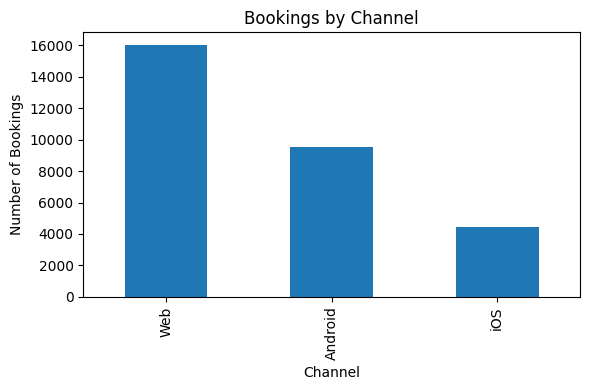

In [11]:
import matplotlib.pyplot as plt

channel_counts = df['channel_of_booking'].value_counts()

plt.figure(figsize=(6,4))
channel_counts.plot(kind='bar')
plt.title('Bookings by Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

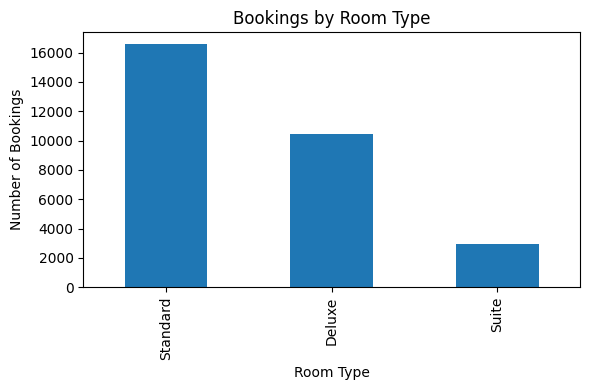

In [12]:
import matplotlib.pyplot as plt

room_counts = df['room_type'].value_counts()

plt.figure(figsize=(6,4))
room_counts.plot(kind='bar')
plt.title('Bookings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

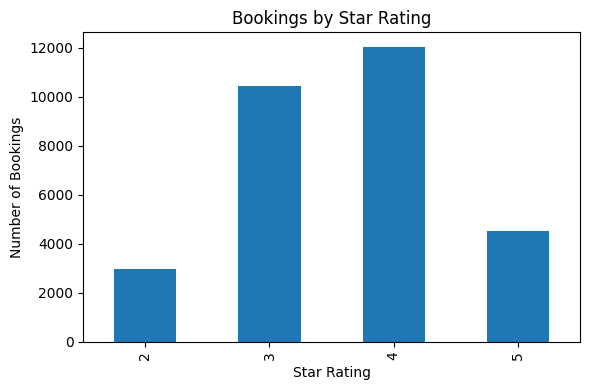

In [13]:
import matplotlib.pyplot as plt

star_counts = df['star_rating'].value_counts().sort_index()

plt.figure(figsize=(6,4))
star_counts.plot(kind='bar')
plt.title('Bookings by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

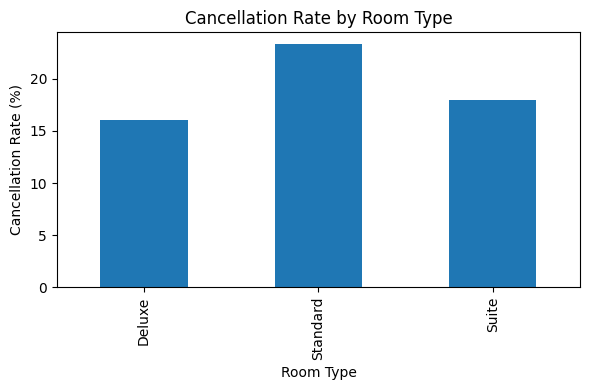

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

cancel_rate = pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
) * 100

cancel_rate['Cancelled'].plot(kind='bar', figsize=(6,4))

plt.title('Cancellation Rate by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

In [15]:
import os
os.makedirs("charts", exist_ok=True)

# Chart 1
df['channel_of_booking'].value_counts().plot(kind='bar')
plt.title('Bookings by Channel')
plt.tight_layout()
plt.savefig('charts/chart1_bookings_by_channel.png')
plt.close()

# Chart 2
df['room_type'].value_counts().plot(kind='bar')
plt.title('Bookings by Room Type')
plt.tight_layout()
plt.savefig('charts/chart2_room_type.png')
plt.close()

# Chart 3
df['star_rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Bookings by Star Rating')
plt.tight_layout()
plt.savefig('charts/chart3_star_rating.png')
plt.close()

# Chart 4
cancel_rate = pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
) * 100

cancel_rate['Cancelled'].plot(kind='bar')
plt.title('Cancellation Rate by Room Type')
plt.tight_layout()
plt.savefig('charts/chart4_cancellation_rate.png')
plt.close()

print("All charts saved successfully!")

All charts saved successfully!


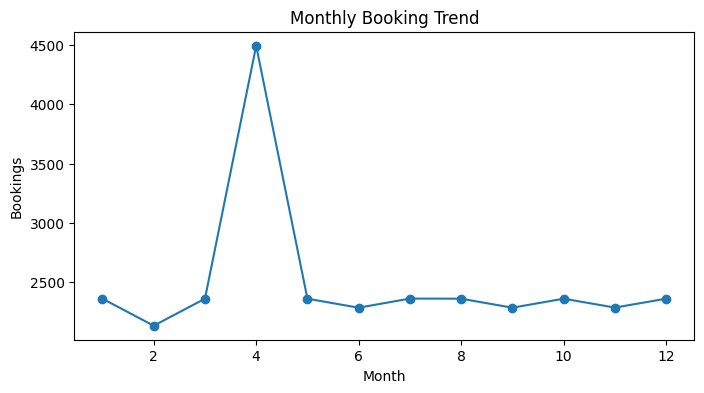

booking_date
1     2360
2     2132
3     2360
4     4494
5     2360
6     2284
7     2361
8     2360
9     2284
10    2360
11    2285
12    2360
dtype: int64


In [16]:
df['booking_date'] = pd.to_datetime(df['booking_date'])

monthly_bookings = df.groupby(df['booking_date'].dt.month).size()

monthly_bookings.plot(kind='line', marker='o', figsize=(8,4))
plt.title('Monthly Booking Trend')
plt.xlabel('Month')
plt.ylabel('Bookings')
plt.show()

print(monthly_bookings)

In [17]:
df['booking_date'] = pd.to_datetime(df['booking_date'])

monthly_bookings = df.groupby(df['booking_date'].dt.month).size()

print(monthly_bookings)

booking_date
1     2360
2     2132
3     2360
4     4494
5     2360
6     2284
7     2361
8     2360
9     2284
10    2360
11    2285
12    2360
dtype: int64
